# Fire Season Timing: Exploratory Data Analysis

In [1]:
'''
05_02_REG_eda.ipynb
Exploratory data analysis notebook for fire season timing metrics.

Sections:
  Section 1:  Timing metric distributions  (onset, peak, end, season length)
  Section 2:  Profile shape & bimodality   (concentration, skewness, BC, scatter matrix)
  Section 3:  Ridgeline plot               (seasonal fire distribution per ecoregion)

No GEE connection required. Reads entirely from disk.

Inputs  : master_<RUN_LABEL>_<RUN_VERSION>.csv
          _all_daily_counts.csv
          _eco_quality.csv

Outputs : plots/01_timing_distributions.png
          plots/02_season_length_histograms.png
          plots/03_season_length_boxplot.png
          plots/05_profile_shape_concentration_skewness.png
          plots/06_bimodality_bc.png
          plots/07_bimodal_flag_distributions.png
          plots/08_ecoregion_quality_cv_correlation.png
          plots/09_scatter_matrix_shape_bimodality.png
          plots/XX_ridgeline_<metric>_<order>_<color>.png
'''

import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns

warnings.filterwarnings('ignore')
print('Libraries loaded.')


Libraries loaded.


In [4]:
# RUN CONFIGURATION -------------------------------------------------------------------------------
# Match these to the pipeline run you want to validate.

RUN_LABEL   = 'med_basin'
RUN_VERSION = 'v3'

# Windows path file
# BASE_OUT_DIR = r'C:\Users\ibekar\Documents\GitProjects\TGPF'
# Mac path file
BASE_OUT_DIR = "/Users/ibekar/Github/TGPF"

# Derived paths:  do not edit below this line
_run_name   = f'{RUN_LABEL}_{RUN_VERSION}'
output_dir  = os.path.join(BASE_OUT_DIR, 'outputs', _run_name)
daily_dir   = os.path.join(output_dir, 'daily_counts')
plots_dir = os.path.join(output_dir, 'plots')
profile_dir = os.path.join(plots_dir, 'profile_plots')

os.makedirs(plots_dir, exist_ok=True)
os.makedirs(profile_dir, exist_ok=True)

# BIMODALITY THRESHOLDS:  must match values used in pipeline ----------------------
BC_THRESHOLD     = 0.555

# PLOT STYLE ----------------------------------------------------------------------
C_ONSET  = '#2ca02c'
C_PEAK   = '#d62728'
C_MEDIAN = '#ff7f0e'
C_CONC   = '#aec7e8'
C_FLAGS  = {0: '#1f77b4', 1: '#d62728'}
L_FLAGS  = {0: 'Clean (0)', 1: 'Flagged (1)'}
FIG_DPI  = 150

# Month start DOYs and labels for x-axis ticks (non-leap year)
MONTH_STARTS = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
MONTH_NAMES  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f'Run       : {_run_name}')
print(f'Output dir: {output_dir}')
print(f'Plots dir: {plots_dir}')
print(f'Profiles  : {profile_dir}')

Run       : med_basin_v3
Output dir: /Users/ibekar/Github/TGPF/outputs/med_basin_v3
Plots dir: /Users/ibekar/Github/TGPF/outputs/med_basin_v3/plots
Profiles  : /Users/ibekar/Github/TGPF/outputs/med_basin_v3/plots/profile_plots


## Load Data

In [5]:
# LOAD DATA ---------------------------------------------------------------------------------------

master_path  = os.path.join(output_dir, f'master_{_run_name}.csv')
daily_path   = os.path.join(output_dir, '_all_daily_counts.csv')
quality_path = os.path.join(output_dir, '_eco_quality.csv')
geo_path     = os.path.join(output_dir, 'eco_geometries.json')

master_df  = pd.read_csv(master_path)
daily_df   = pd.read_csv(daily_path)
quality_df = pd.read_csv(quality_path)

with open(geo_path, 'r') as f:
    geo_data = json.load(f)

# Geometry lookup: eco_id → GeoJSON geometry dict (used in map plot)
geo_lookup = {rec['eco_id']: rec['geometry'] for rec in geo_data}

# Ecoregion reference table:  one stable row per ecoregion
eco_ref = master_df.groupby('eco_id').agg(
    eco_name  = ('eco_name',   'first'),
    biome_num = ('biome_num',  'first'),
    biome_name= ('biome_name', 'first'),
).reset_index()

n_eco  = master_df['eco_id'].nunique()
n_rows = len(master_df)


print('Columns in master CSV:')
for col in master_df.columns:
    print(f'  {col}')
print()
print(f'Master CSV : {n_rows} rows:  {n_eco} ecoregions')
print(f'Daily CSV  : {len(daily_df)} rows')
print(f'Quality CSV: {len(quality_df)} ecoregions')
print(f'Geometries : {len(geo_data)} ecoregions')


Columns in master CSV:
  eco_id
  eco_name
  biome_num
  biome_name
  year
  onset_doy
  peak_doy
  end_doy
  season_length
  n_detections
  onset_month
  peak_month
  onset_doy_10
  end_doy_90
  onset_doy_15
  end_doy_85
  median_doy
  mean_median_div
  q25_doy
  q75_doy
  iqr_season_length
  active_days
  peak_concentration
  skewness
  kurtosis_raw
  bc
  bimodal_flag_year
  peak_outside_window
  n_years_valid
  pct_years_valid
  cv_peak_doy
  mean_profile_corr
  frac_flagged
  bimodal_flag_eco

Master CSV : 1301 rows:  58 ecoregions
Daily CSV  : 495659 rows
Quality CSV: 58 ecoregions
Geometries : 59 ecoregions


## Section 1: Timing Metric Distributions

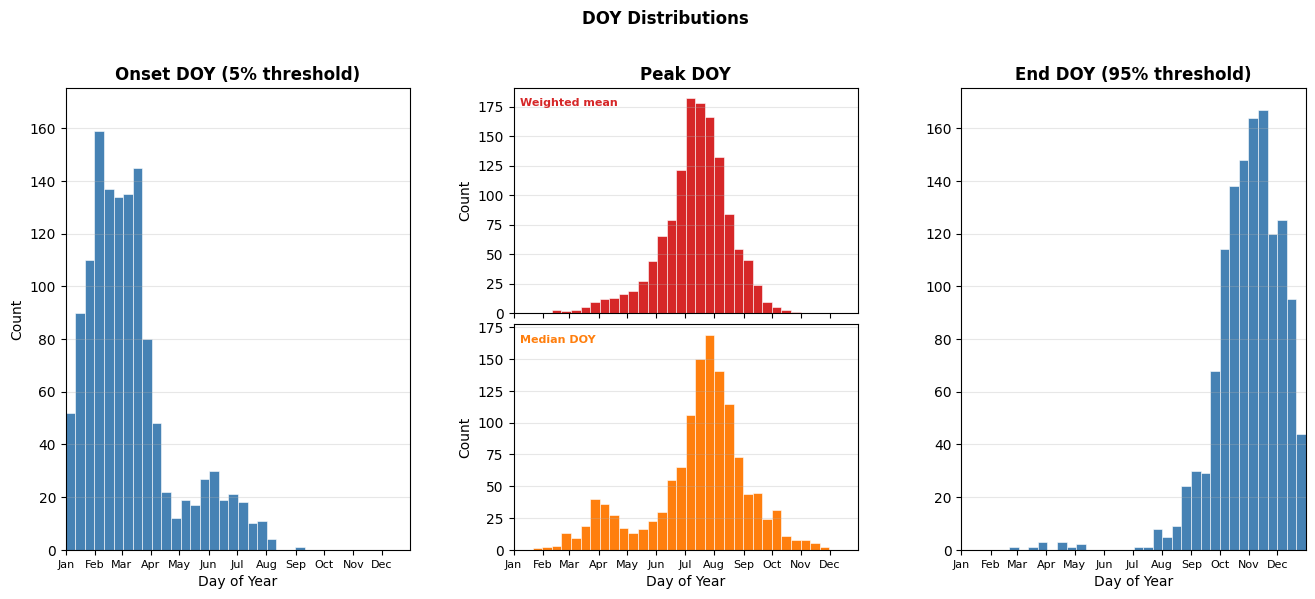

In [4]:
# PLOT 01: DOY DISTRIBUTIONS ------------------------------------------------------
# Onset, peak, and end DOY distributions pooled across all ecoregions and years

from matplotlib.gridspec import GridSpec

def set_month_ticks(ax):
    ax.set_xticks(MONTH_STARTS)
    ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_xlim(1, 365)

fig = plt.figure(figsize=(16, 6))
fig.suptitle('DOY Distributions',
             fontsize=12, fontweight='bold', y=1.01)

bin_edges = np.linspace(1, 365, 37)

gs = GridSpec(2, 3, figure=fig, hspace=0.05, wspace=0.3)

# 01a - Onset DOY (spans both rows)
ax1 = fig.add_subplot(gs[:, 0])
ax1.hist(master_df['onset_doy'].dropna(), bins=bin_edges,
         color='steelblue', edgecolor='white', linewidth=0.4)
set_month_ticks(ax1)
ax1.set_title('Onset DOY (5% threshold)', fontweight='bold')
ax1.set_xlabel('Day of Year')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

# 01b - Weighted mean peak
ax2a = fig.add_subplot(gs[0, 1])
ax2a.hist(master_df['peak_doy'].dropna(), bins=bin_edges,
          color=C_PEAK, edgecolor='white', linewidth=0.4)
ax2a.set_title('Peak DOY', fontweight='bold')
ax2a.set_ylabel('Count')
ax2a.tick_params(labelbottom=False)
ax2a.text(0.02, 0.92, 'Weighted mean', transform=ax2a.transAxes,
          fontsize=8, color=C_PEAK, fontweight='bold')
ax2a.grid(axis='y', alpha=0.3)
ax2a.set_xlim(1, 365)

# 01b - Median DOY
ax2b = fig.add_subplot(gs[1, 1], sharex=ax2a)
ax2b.hist(master_df['median_doy'].dropna(), bins=bin_edges,
          color=C_MEDIAN, edgecolor='white', linewidth=0.4)
ax2b.set_ylabel('Count')
ax2b.text(0.02, 0.92, 'Median DOY', transform=ax2b.transAxes,
          fontsize=8, color=C_MEDIAN, fontweight='bold')
ax2b.grid(axis='y', alpha=0.3)
set_month_ticks(ax2b)
ax2b.set_xlabel('Day of Year')

# 01c - End DOY (spans both rows)
ax3 = fig.add_subplot(gs[:, 2])
ax3.hist(master_df['end_doy'].dropna(), bins=bin_edges,
         color='steelblue', edgecolor='white', linewidth=0.4)
set_month_ticks(ax3)
ax3.set_title('End DOY (95% threshold)', fontweight='bold')
ax3.set_xlabel('Day of Year')
ax3.grid(axis='y', alpha=0.3)

# Force matplotlib to finalize all axis limits before reading them
plt.draw()

# Share y-axis between 01a and 01c
shared_ymax = max(ax1.get_ylim()[1], ax3.get_ylim()[1])
ax1.set_ylim(0, shared_ymax)
ax3.set_ylim(0, shared_ymax)

plt.savefig(os.path.join(plots_dir, '01_timing_distributions.png'), 
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()

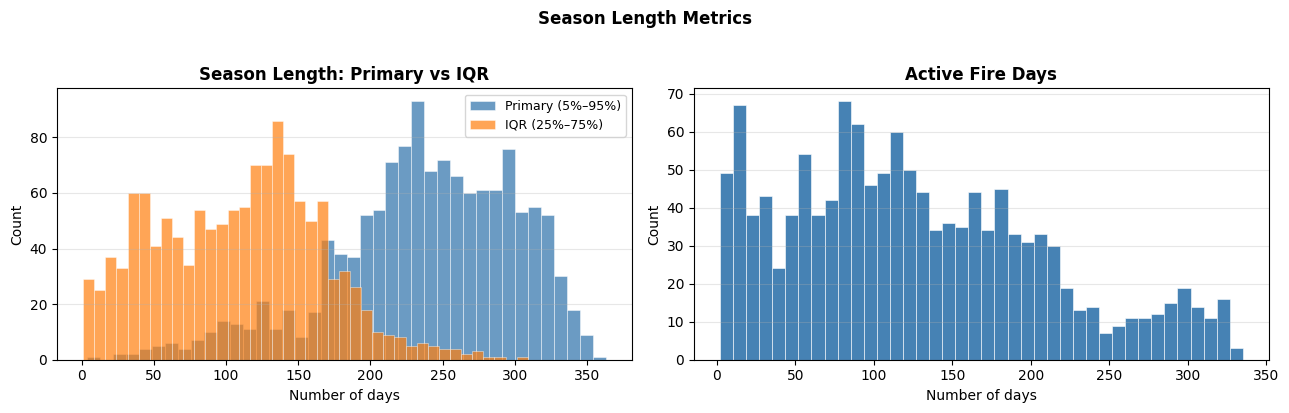

In [5]:
# PLOT 02: SEASON LENGTH HISTOGRAMS ------------------------------------------------------------
# 02a: Primary season_length vs IQR season length: overlapping histograms.
#      IQR version should be consistently shorter; wide divergence flags tail inflation.
# 02b: Active days count within the onset–end window.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Season Length Metrics',
             fontsize=12, fontweight='bold', y=1.02)

# 02a - Season length comparison
ax = axes[0]
ax.hist(master_df['season_length'].dropna(), bins=40,
        color='steelblue', edgecolor='white', linewidth=0.4,
        alpha=0.8, label='Primary (5%–95%)')
ax.hist(master_df['iqr_season_length'].dropna(), bins=40,
        color=C_MEDIAN, edgecolor='white', linewidth=0.4,
        alpha=0.7, label='IQR (25%–75%)')
ax.set_title('Season Length: Primary vs IQR', fontweight='bold')
ax.set_xlabel('Number of days')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 02b - Active days
ax = axes[1]
ax.hist(master_df['active_days'].dropna(), bins=40,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Active Fire Days',
             fontweight='bold')
ax.set_xlabel('Number of days')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(os.path.join(plots_dir, "02_season_length_histograms.png"),
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()

In [6]:
# SEASON LENGTH DIAGNOSTICS -----------------------------------------------------------------------
# 1. Summary statistics for season_length and iqr_season_length across all rows.
# 2. Ecoregions where mean season_length > 200 days: desert tail-inflation candidates.

# 1. Summary stats
print('=== Summary Stats ===')
print(master_df[['season_length', 'iqr_season_length']].describe().round(1))

# 2. onset > end bug check
bad_rows = master_df[master_df['onset_doy'] > master_df['end_doy']]
print(f'\n=== onset_doy > end_doy: {len(bad_rows)} rows ===')
if not bad_rows.empty:
    print(bad_rows[['eco_id', 'eco_name', 'year', 'onset_doy', 'end_doy', 'season_length']])

# 3. Ecoregions with season_length > 200
long_seasons = (
    master_df[master_df['season_length'] > 200]
    .groupby(['eco_id', 'eco_name'])
    .agg(n_years=('year', 'count'),
         mean_season_length=('season_length', 'mean'),
         mean_onset=('onset_doy', 'mean'),
         mean_end=('end_doy', 'mean'))
    .round(1)
    .sort_values('mean_season_length', ascending=False)
)
print(f'\n=== Ecoregions with season_length > 200 ({len(long_seasons)} ecoregions) ===')
print(long_seasons.to_string())


=== Summary Stats ===
       season_length  iqr_season_length
count         1301.0             1301.0
mean           237.2              108.7
std             64.1               57.1
min              4.0                1.0
25%            202.0               60.0
50%            241.0              114.0
75%            287.0              148.0
max            363.0              309.0

=== onset_doy > end_doy: 0 rows ===

=== Ecoregions with season_length > 200 (58 ecoregions) ===
                                                                          n_years  mean_season_length  mean_onset  mean_end
eco_id eco_name                                                                                                            
809    Arabian desert                                                          23               324.1        21.3     344.4
837    Red Sea-Arabian Desert shrublands                                       23               316.7        22.1     337.9
796    Mediterranean Aca

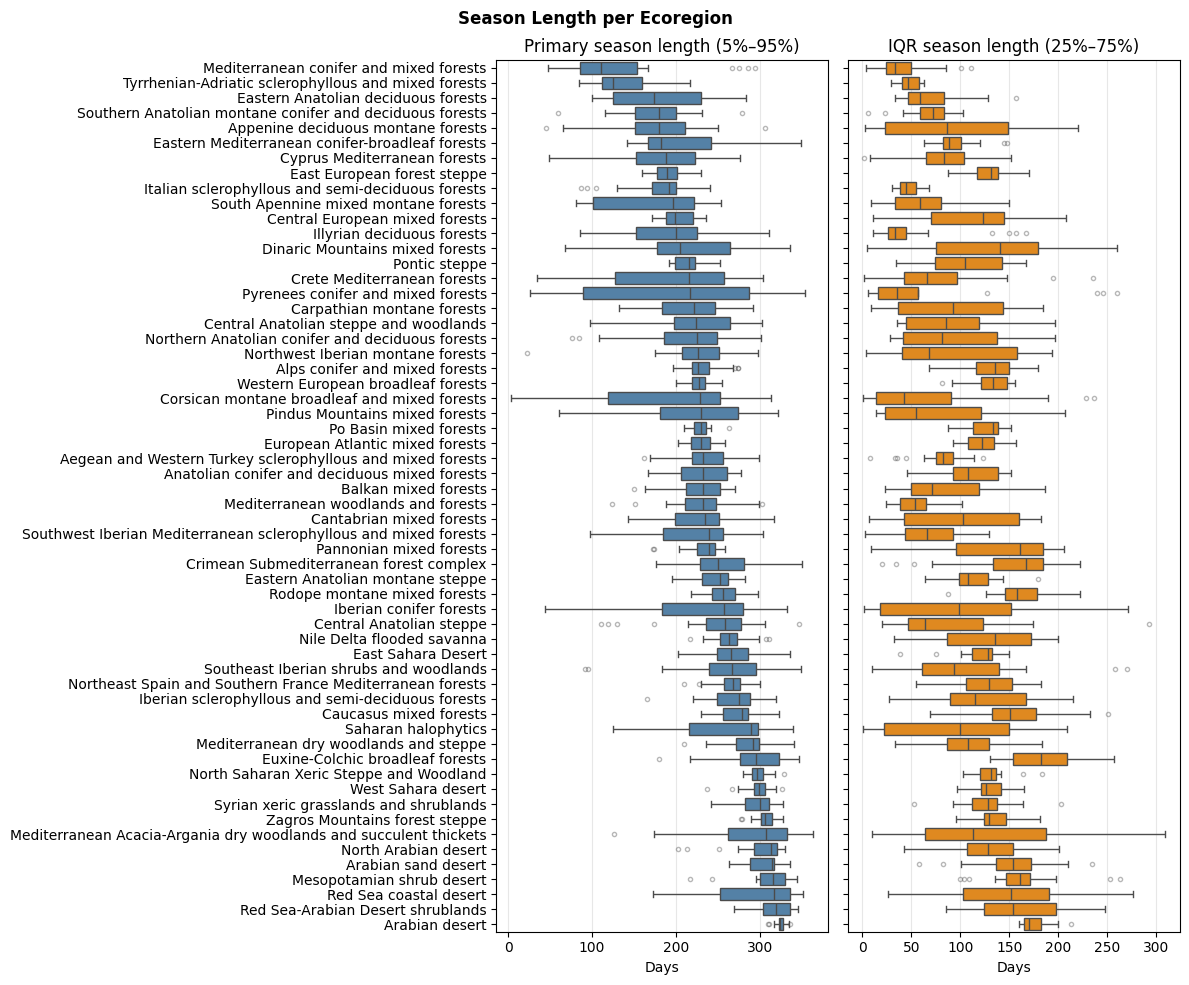

In [7]:
# PLOT 03: SEASON LENGTH BOXPLOT PER ECOREGION -----------------------------------------------------
# Primary season length (5%–95%) vs IQR season length (25%–75%) broken out per ecoregion.
# Sorted by median primary season length.
# Wide gap between primary and IQR boxes = tail inflation from sparse detections.

eco_order = (
    master_df.groupby('eco_name')['season_length']
    .median()
    .sort_values(ascending=True)   # ascending=True so longest is at the top
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 10))   # side-by-side instead of stacked
fig.suptitle('Season Length per Ecoregion', fontweight='bold')

sns.boxplot(data=master_df, y='eco_name', x='season_length',
            order=eco_order, ax=axes[0],
            color='steelblue', flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[0].set_title('Primary season length (5%–95%)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('')
axes[0].grid(axis='x', alpha=0.3)

sns.boxplot(data=master_df, y='eco_name', x='iqr_season_length',
            order=eco_order, ax=axes[1],
            color='darkorange', flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('IQR season length (25%–75%)')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])   # labels already shown on left panel
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '03_season_length_boxplot.png'),
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()

## Section 2: Profile Shape & Bimodality

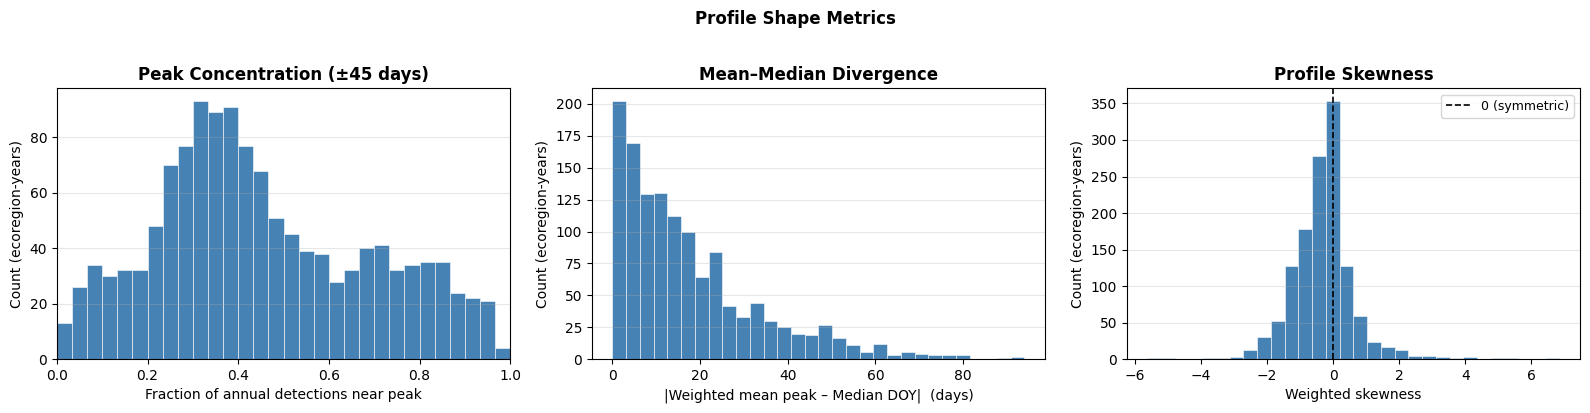

In [8]:
# PLOT 05: PROFILE SHAPE METRICS -------------------------------------------------------------------
# Peak concentration:  fraction of detections within ±45 days of peak.
#      Low values flag diffuse or potentially bimodal activity.
# Mean–median divergence in days.
#      Large values flag asymmetric seasons where threshold metrics may be unreliable.
# Weighted skewness of the detection profile.
#      Positive = long right tail (slow end). Negative = long left tail (slow start).

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Profile Shape Metrics',
             fontsize=12, fontweight='bold', y=1.02)

# 05a: Peak concentration
ax = axes[0]
ax.hist(master_df['peak_concentration'].dropna(), bins=30,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Peak Concentration (±45 days)', fontweight='bold')
ax.set_xlabel('Fraction of annual detections near peak')
ax.set_ylabel('Count (ecoregion-years)')
ax.set_xlim(0, 1)
ax.grid(axis='y', alpha=0.3)

# 05b: Mean–median divergence
ax = axes[1]
ax.hist(master_df['mean_median_div'].dropna(), bins=30,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Mean–Median Divergence', fontweight='bold')
ax.set_xlabel('|Weighted mean peak – Median DOY|  (days)')
ax.set_ylabel('Count (ecoregion-years)')
ax.grid(axis='y', alpha=0.3)

# 05c: Skewness
ax = axes[2]
ax.hist(master_df['skewness'].dropna(), bins=30,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='0 (symmetric)')
ax.set_title('Profile Skewness', fontweight='bold')
ax.set_xlabel('Weighted skewness')
ax.set_ylabel('Count (ecoregion-years)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_profile_shape_concentration_skewness.png"),
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()

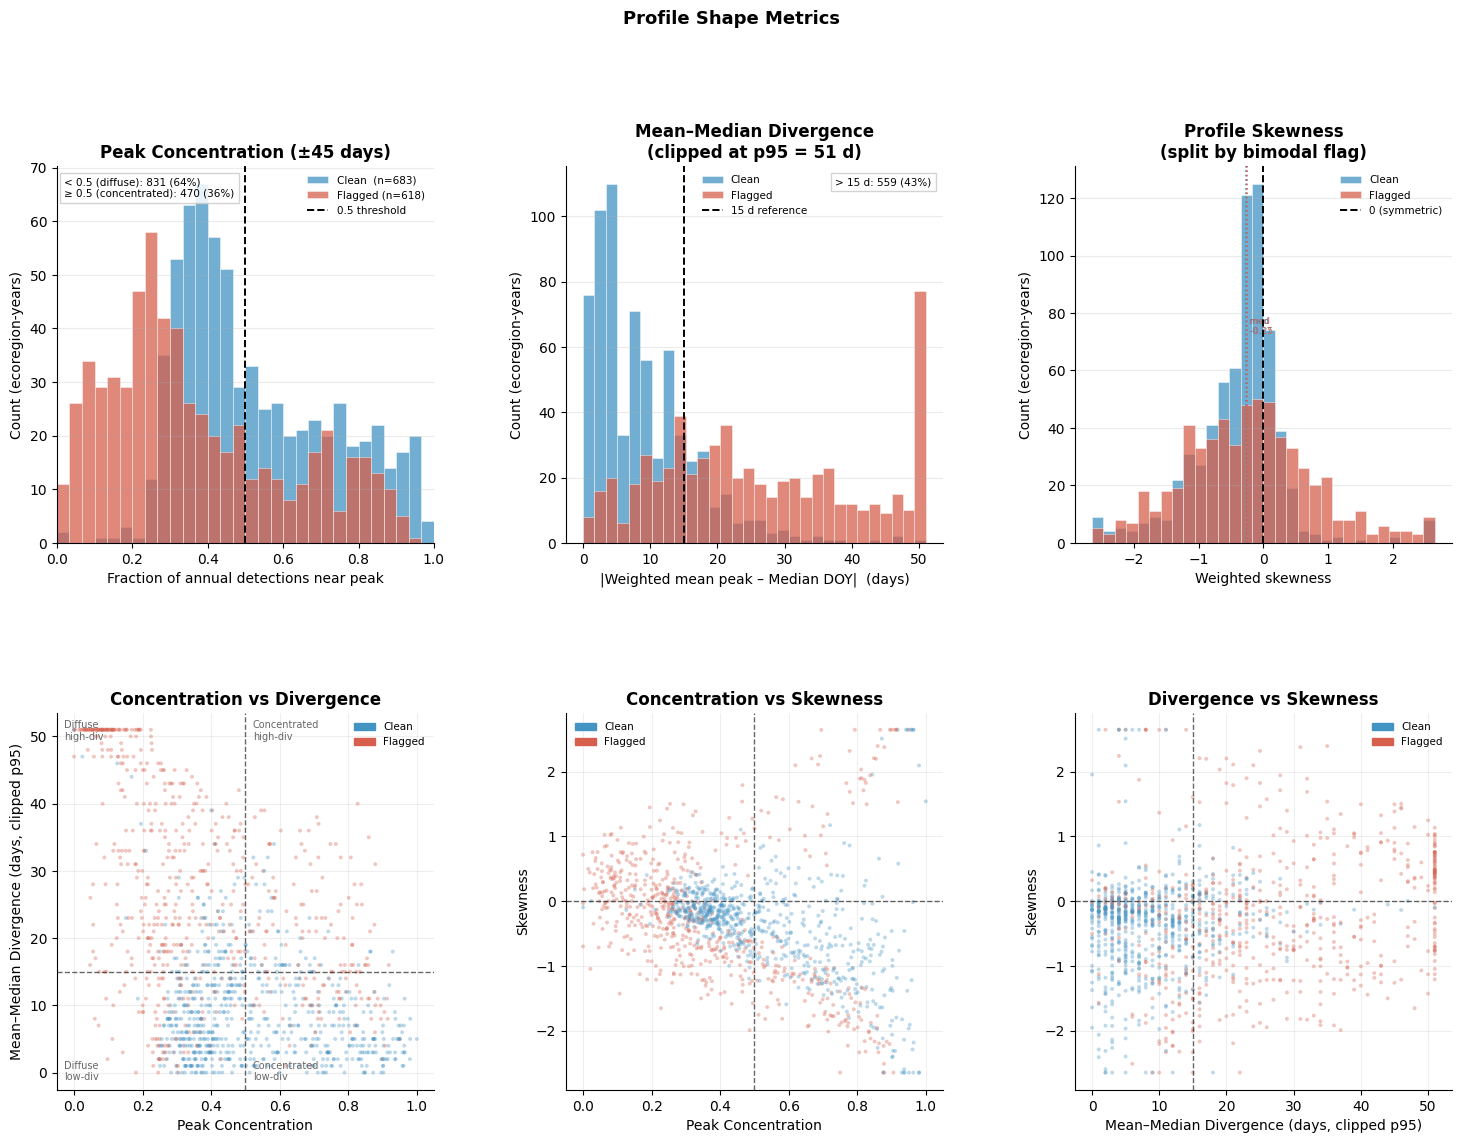

In [6]:
# PLOT 05: PROFILE SHAPE METRICS (REVAMPED) -------------------------------------------------------

from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── HELPERS ───────────────────────────────────────────────────────────────────
def add_percentile_lines(ax, data, percentiles=(25, 50, 75), orient='v'):
    for p in percentiles:
        val = np.nanpercentile(data, p)
        lw  = 1.6 if p == 50 else 1.0
        ls  = '-' if p == 50 else '--'
        if orient == 'v':
            ax.axvline(val, color='#444444', linewidth=lw, linestyle=ls, zorder=3)
            ax.text(val, ax.get_ylim()[1] * 0.97, f' p{p}\n {val:.2f}',
                    fontsize=6.5, va='top', ha='left', color='#444444')
        else:
            ax.axhline(val, color='#444444', linewidth=lw, linestyle=ls, zorder=3)

def flag_split_colors(df):
    '''Return color array based on bimodal_flag_year.'''
    return df['bimodal_flag_year'].map({0: '#4393c3', 1: '#d6604d'}).fillna('#aaaaaa')

CLEAN_C   = '#4393c3'
FLAG_C    = '#d6604d'
ALPHA_H   = 0.75

clean_df  = master_df[master_df['bimodal_flag_year'] == 0]
flag_df   = master_df[master_df['bimodal_flag_year'] == 1]

# ── PANEL 1 (top-left): Peak Concentration — full population ─────────────────
ax1 = fig.add_subplot(gs[0, 0])

conc_vals = master_df['peak_concentration'].dropna()
bins_conc = np.linspace(0, 1, 31)

ax1.hist(clean_df['peak_concentration'].dropna(), bins=bins_conc,
         color=CLEAN_C, edgecolor='white', linewidth=0.4,
         alpha=ALPHA_H, label=f'Clean  (n={len(clean_df)})')
ax1.hist(flag_df['peak_concentration'].dropna(), bins=bins_conc,
         color=FLAG_C, edgecolor='white', linewidth=0.4,
         alpha=ALPHA_H, label=f'Flagged (n={len(flag_df)})')

ax1.axvline(0.5, color='black', linewidth=1.4, linestyle='--', zorder=4,
            label='0.5 threshold')

# Count above/below threshold
n_diffuse    = int((conc_vals < 0.5).sum())
n_conc       = int((conc_vals >= 0.5).sum())
ax1.text(0.02, 0.97,
         f'< 0.5 (diffuse): {n_diffuse} ({n_diffuse/len(conc_vals)*100:.0f}%)\n'
         f'≥ 0.5 (concentrated): {n_conc} ({n_conc/len(conc_vals)*100:.0f}%)',
         transform=ax1.transAxes, fontsize=7.5, va='top',
         bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.85, pad=3))

ax1.set_title('Peak Concentration (±45 days)', fontweight='bold')
ax1.set_xlabel('Fraction of annual detections near peak')
ax1.set_ylabel('Count (ecoregion-years)')
ax1.set_xlim(0, 1)
ax1.legend(fontsize=7.5, frameon=False)
ax1.grid(axis='y', alpha=0.25)
ax1.spines[['top', 'right']].set_visible(False)

# ── PANEL 2 (top-middle): Mean–Median Divergence — clipped + log x ───────────
ax2 = fig.add_subplot(gs[0, 1])

div_vals  = master_df['mean_median_div'].dropna()
clip_p95  = np.nanpercentile(div_vals, 95)
div_clip  = div_vals.clip(upper=clip_p95)

bins_div  = np.linspace(0, clip_p95, 31)

ax2.hist(clean_df['mean_median_div'].dropna().clip(upper=clip_p95),
         bins=bins_div, color=CLEAN_C, edgecolor='white', linewidth=0.4,
         alpha=ALPHA_H, label='Clean')
ax2.hist(flag_df['mean_median_div'].dropna().clip(upper=clip_p95),
         bins=bins_div, color=FLAG_C, edgecolor='white', linewidth=0.4,
         alpha=ALPHA_H, label='Flagged')

# Reference threshold at 15 days
ax2.axvline(15, color='black', linewidth=1.4, linestyle='--', zorder=4,
            label='15 d reference')

n_high_div = int((div_vals > 15).sum())
ax2.text(0.97, 0.97,
         f'> 15 d: {n_high_div} ({n_high_div/len(div_vals)*100:.0f}%)',
         transform=ax2.transAxes, fontsize=7.5, va='top', ha='right',
         bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.85, pad=3))

ax2.set_title(f'Mean–Median Divergence\n(clipped at p95 = {clip_p95:.0f} d)',
              fontweight='bold')
ax2.set_xlabel('|Weighted mean peak – Median DOY|  (days)')
ax2.set_ylabel('Count (ecoregion-years)')
ax2.legend(fontsize=7.5, frameon=False)
ax2.grid(axis='y', alpha=0.25)
ax2.spines[['top', 'right']].set_visible(False)

# ── PANEL 3 (top-right): Skewness split by flag ───────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

skew_all   = master_df['skewness'].dropna()
skew_clip  = np.nanpercentile(np.abs(skew_all), 98)
bins_skew  = np.linspace(-skew_clip, skew_clip, 31)

ax3.hist(clean_df['skewness'].dropna().clip(-skew_clip, skew_clip),
         bins=bins_skew, color=CLEAN_C, edgecolor='white', linewidth=0.4,
         alpha=ALPHA_H, label='Clean')
ax3.hist(flag_df['skewness'].dropna().clip(-skew_clip, skew_clip),
         bins=bins_skew, color=FLAG_C, edgecolor='white', linewidth=0.4,
         alpha=ALPHA_H, label='Flagged')

ax3.axvline(0, color='black', linewidth=1.4, linestyle='--', zorder=4,
            label='0 (symmetric)')

# Median lines per group
for df_grp, color, label in [(clean_df, CLEAN_C, 'clean'), (flag_df, FLAG_C, 'flagged')]:
    med = df_grp['skewness'].median()
    ax3.axvline(med, color=color, linewidth=1.2, linestyle=':', zorder=4)
    ax3.text(med, ax3.get_ylim()[1] * 0.6, f' med\n {med:.2f}',
             fontsize=6.5, color=color, va='top')

ax3.set_title('Profile Skewness\n(split by bimodal flag)', fontweight='bold')
ax3.set_xlabel('Weighted skewness')
ax3.set_ylabel('Count (ecoregion-years)')
ax3.legend(fontsize=7.5, frameon=False)
ax3.grid(axis='y', alpha=0.25)
ax3.spines[['top', 'right']].set_visible(False)

# ── PANEL 4 (bottom-left): Concentration × Divergence scatter ────────────────
ax4 = fig.add_subplot(gs[1, 0])

sc = ax4.scatter(
    master_df['peak_concentration'],
    master_df['mean_median_div'].clip(upper=clip_p95),
    c=master_df['bimodal_flag_year'].map({0: CLEAN_C, 1: FLAG_C}).fillna('#aaaaaa'),
    s=8, alpha=0.35, linewidths=0, zorder=2
)
ax4.axvline(0.5, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
ax4.axhline(15,  color='black', linewidth=1.0, linestyle='--', alpha=0.6)

# Quadrant labels
ax4.text(0.02, 0.98, 'Diffuse\nhigh-div', transform=ax4.transAxes,
         fontsize=7, va='top', color='#666666')
ax4.text(0.52, 0.98, 'Concentrated\nhigh-div', transform=ax4.transAxes,
         fontsize=7, va='top', color='#666666')
ax4.text(0.02, 0.02, 'Diffuse\nlow-div', transform=ax4.transAxes,
         fontsize=7, va='bottom', color='#666666')
ax4.text(0.52, 0.02, 'Concentrated\nlow-div', transform=ax4.transAxes,
         fontsize=7, va='bottom', color='#666666')

handles = [mpatches.Patch(color=CLEAN_C, label='Clean'),
           mpatches.Patch(color=FLAG_C,  label='Flagged')]
ax4.legend(handles=handles, fontsize=7.5, frameon=False)
ax4.set_xlabel('Peak Concentration')
ax4.set_ylabel(f'Mean–Median Divergence (days, clipped p95)')
ax4.set_title('Concentration vs Divergence', fontweight='bold')
ax4.grid(alpha=0.2)
ax4.spines[['top', 'right']].set_visible(False)

# ── PANEL 5 (bottom-middle): Concentration × Skewness scatter ────────────────
ax5 = fig.add_subplot(gs[1, 1])

ax5.scatter(
    master_df['peak_concentration'],
    master_df['skewness'].clip(-skew_clip, skew_clip),
    c=master_df['bimodal_flag_year'].map({0: CLEAN_C, 1: FLAG_C}).fillna('#aaaaaa'),
    s=8, alpha=0.35, linewidths=0, zorder=2
)
ax5.axvline(0.5, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
ax5.axhline(0,   color='black', linewidth=1.0, linestyle='--', alpha=0.6)

ax5.set_xlabel('Peak Concentration')
ax5.set_ylabel('Skewness')
ax5.set_title('Concentration vs Skewness', fontweight='bold')
ax5.legend(handles=handles, fontsize=7.5, frameon=False)
ax5.grid(alpha=0.2)
ax5.spines[['top', 'right']].set_visible(False)

# ── PANEL 6 (bottom-right): Divergence × Skewness scatter ────────────────────
ax6 = fig.add_subplot(gs[1, 2])

ax6.scatter(
    master_df['mean_median_div'].clip(upper=clip_p95),
    master_df['skewness'].clip(-skew_clip, skew_clip),
    c=master_df['bimodal_flag_year'].map({0: CLEAN_C, 1: FLAG_C}).fillna('#aaaaaa'),
    s=8, alpha=0.35, linewidths=0, zorder=2
)
ax6.axvline(15, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
ax6.axhline(0,  color='black', linewidth=1.0, linestyle='--', alpha=0.6)

ax6.set_xlabel(f'Mean–Median Divergence (days, clipped p95)')
ax6.set_ylabel('Skewness')
ax6.set_title('Divergence vs Skewness', fontweight='bold')
ax6.legend(handles=handles, fontsize=7.5, frameon=False)
ax6.grid(alpha=0.2)
ax6.spines[['top', 'right']].set_visible(False)

# ── TITLE ─────────────────────────────────────────────────────────────────────
fig.suptitle('Profile Shape Metrics', fontsize=13, fontweight='bold', y=1.01)

plt.savefig(os.path.join(plots_dir, '05_profile_shape_concentration_skewness.png'),
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()

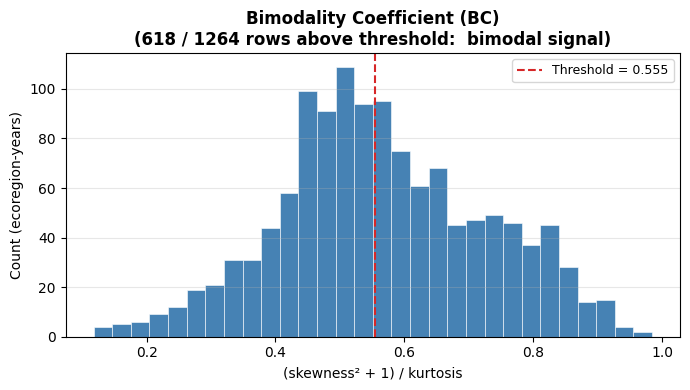

In [9]:
# PLOT 06: BIMODALITY COEFFICIENT (BC) -------------------------------------------------------------
# BC = (skewness² + 1) / kurtosis. Threshold = 0.555 (BC of a uniform distribution).
# BC > threshold suggests the detection profile is more bimodal than uniform.
# Only computed for ecoregion-years where season_length > MIN_SEASON_FOR_BIMODALITY.

fig, ax = plt.subplots(figsize=(7, 4))
bc_vals = master_df['bc'].dropna()
ax.hist(bc_vals, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(BC_THRESHOLD, color=C_PEAK, linewidth=1.5, linestyle='--',
           label=f'Threshold = {BC_THRESHOLD}')
n_above = int((bc_vals > BC_THRESHOLD).sum())
ax.set_title(
    f'Bimodality Coefficient (BC)\n'
    f'({n_above} / {len(bc_vals)} rows above threshold:  bimodal signal)',
    fontweight='bold'
)
ax.set_xlabel('(skewness² + 1) / kurtosis')
ax.set_ylabel('Count (ecoregion-years)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '06_bimodality_bc.png'), dpi=FIG_DPI, bbox_inches='tight')
plt.show()

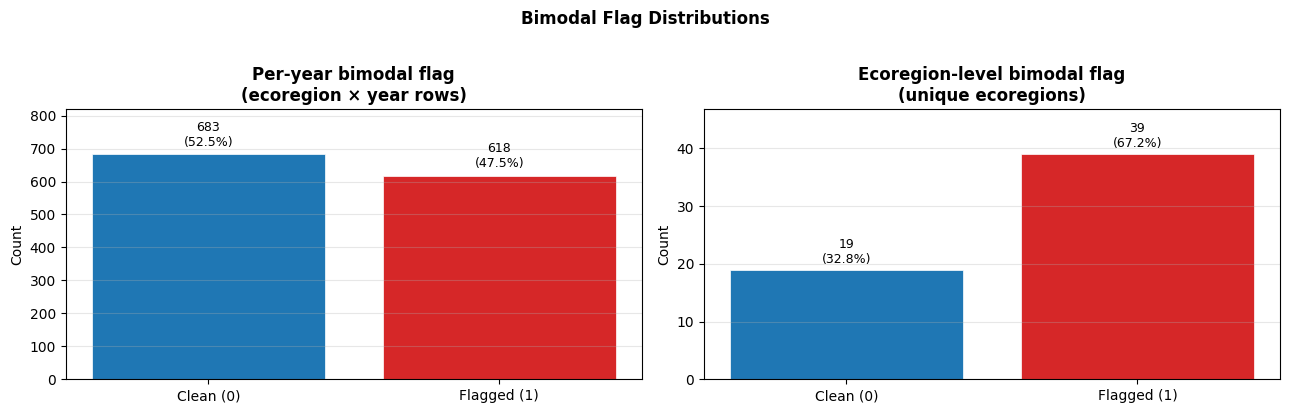

In [10]:
# PLOT 07: BIMODAL FLAG DISTRIBUTIONS --------------------------------------------------------------
# 7a: Per-year bimodal flag (bimodal_flag_year): one bar per flag value across all ecoregion-years.
# 7b: Ecoregion-level bimodal flag (bimodal_flag_eco): one bar per flag value across ecoregions.
# If 80%+ of ecoregion-years are flagged, BC_THRESHOLD may be too loose.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Bimodal Flag Distributions',
             fontsize=12, fontweight='bold', y=1.02)

def flag_bar_chart(ax, series, title):
    counts = series.value_counts().sort_index()
    colors = [C_FLAGS.get(k, '#aaaaaa') for k in counts.index]
    labels = [L_FLAGS.get(k, str(k))    for k in counts.index]
    bars   = ax.bar(labels, counts.values, color=colors,
                    edgecolor='white', linewidth=0.5)
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.012,
            f'{val}\n({val / total * 100:.1f}%)',
            ha='center', va='bottom', fontsize=9
        )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.20)
    ax.grid(axis='y', alpha=0.3)

flag_bar_chart(
    axes[0], master_df['bimodal_flag_year'],
    'Per-year bimodal flag\n(ecoregion × year rows)'
)
flag_bar_chart(
    axes[1], quality_df['bimodal_flag_eco'],
    'Ecoregion-level bimodal flag\n(unique ecoregions)'
)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '07_bimodal_flag_distributions.png'), dpi=FIG_DPI, bbox_inches='tight')
plt.show()

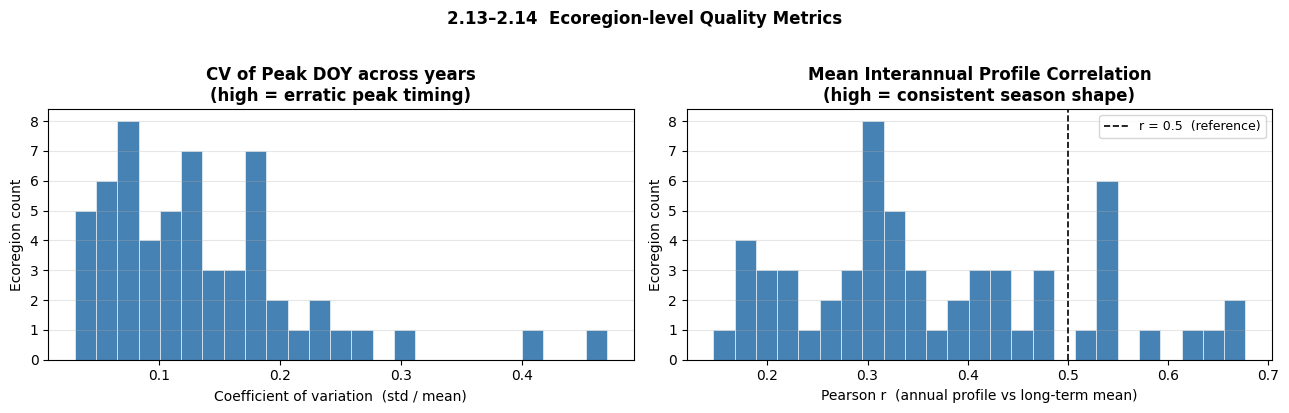

In [11]:
# PLOT 08: Ecoregion-level Quality Metrics  --------------------------------------------------------
# These are computed across years per ecoregion and live in _eco_quality.csv.
# 8a CV of peak DOY:  std / mean across valid years. High = erratic timing.
# 8b Mean interannual profile correlation. High = consistent season shape year to year.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('2.13–2.14  Ecoregion-level Quality Metrics',
             fontsize=12, fontweight='bold', y=1.02)

# 8a CV of peak DOY
ax = axes[0]
cv_vals = quality_df['cv_peak_doy'].dropna()
ax.hist(cv_vals, bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('CV of Peak DOY across years\n(high = erratic peak timing)',
             fontweight='bold')
ax.set_xlabel('Coefficient of variation  (std / mean)')
ax.set_ylabel('Ecoregion count')
ax.grid(axis='y', alpha=0.3)

# 8b Mean interannual profile correlation
ax = axes[1]
corr_vals = quality_df['mean_profile_corr'].dropna()
ax.hist(corr_vals, bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0.5, color='black', linewidth=1.2, linestyle='--',
           label='r = 0.5  (reference)')
ax.set_title('Mean Interannual Profile Correlation\n'
             '(high = consistent season shape)',
             fontweight='bold')
ax.set_xlabel("Pearson r  (annual profile vs long-term mean)")
ax.set_ylabel('Ecoregion count')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '08_ecoregion_quality_cv_correlation.png'), dpi=FIG_DPI, bbox_inches='tight')
plt.show()

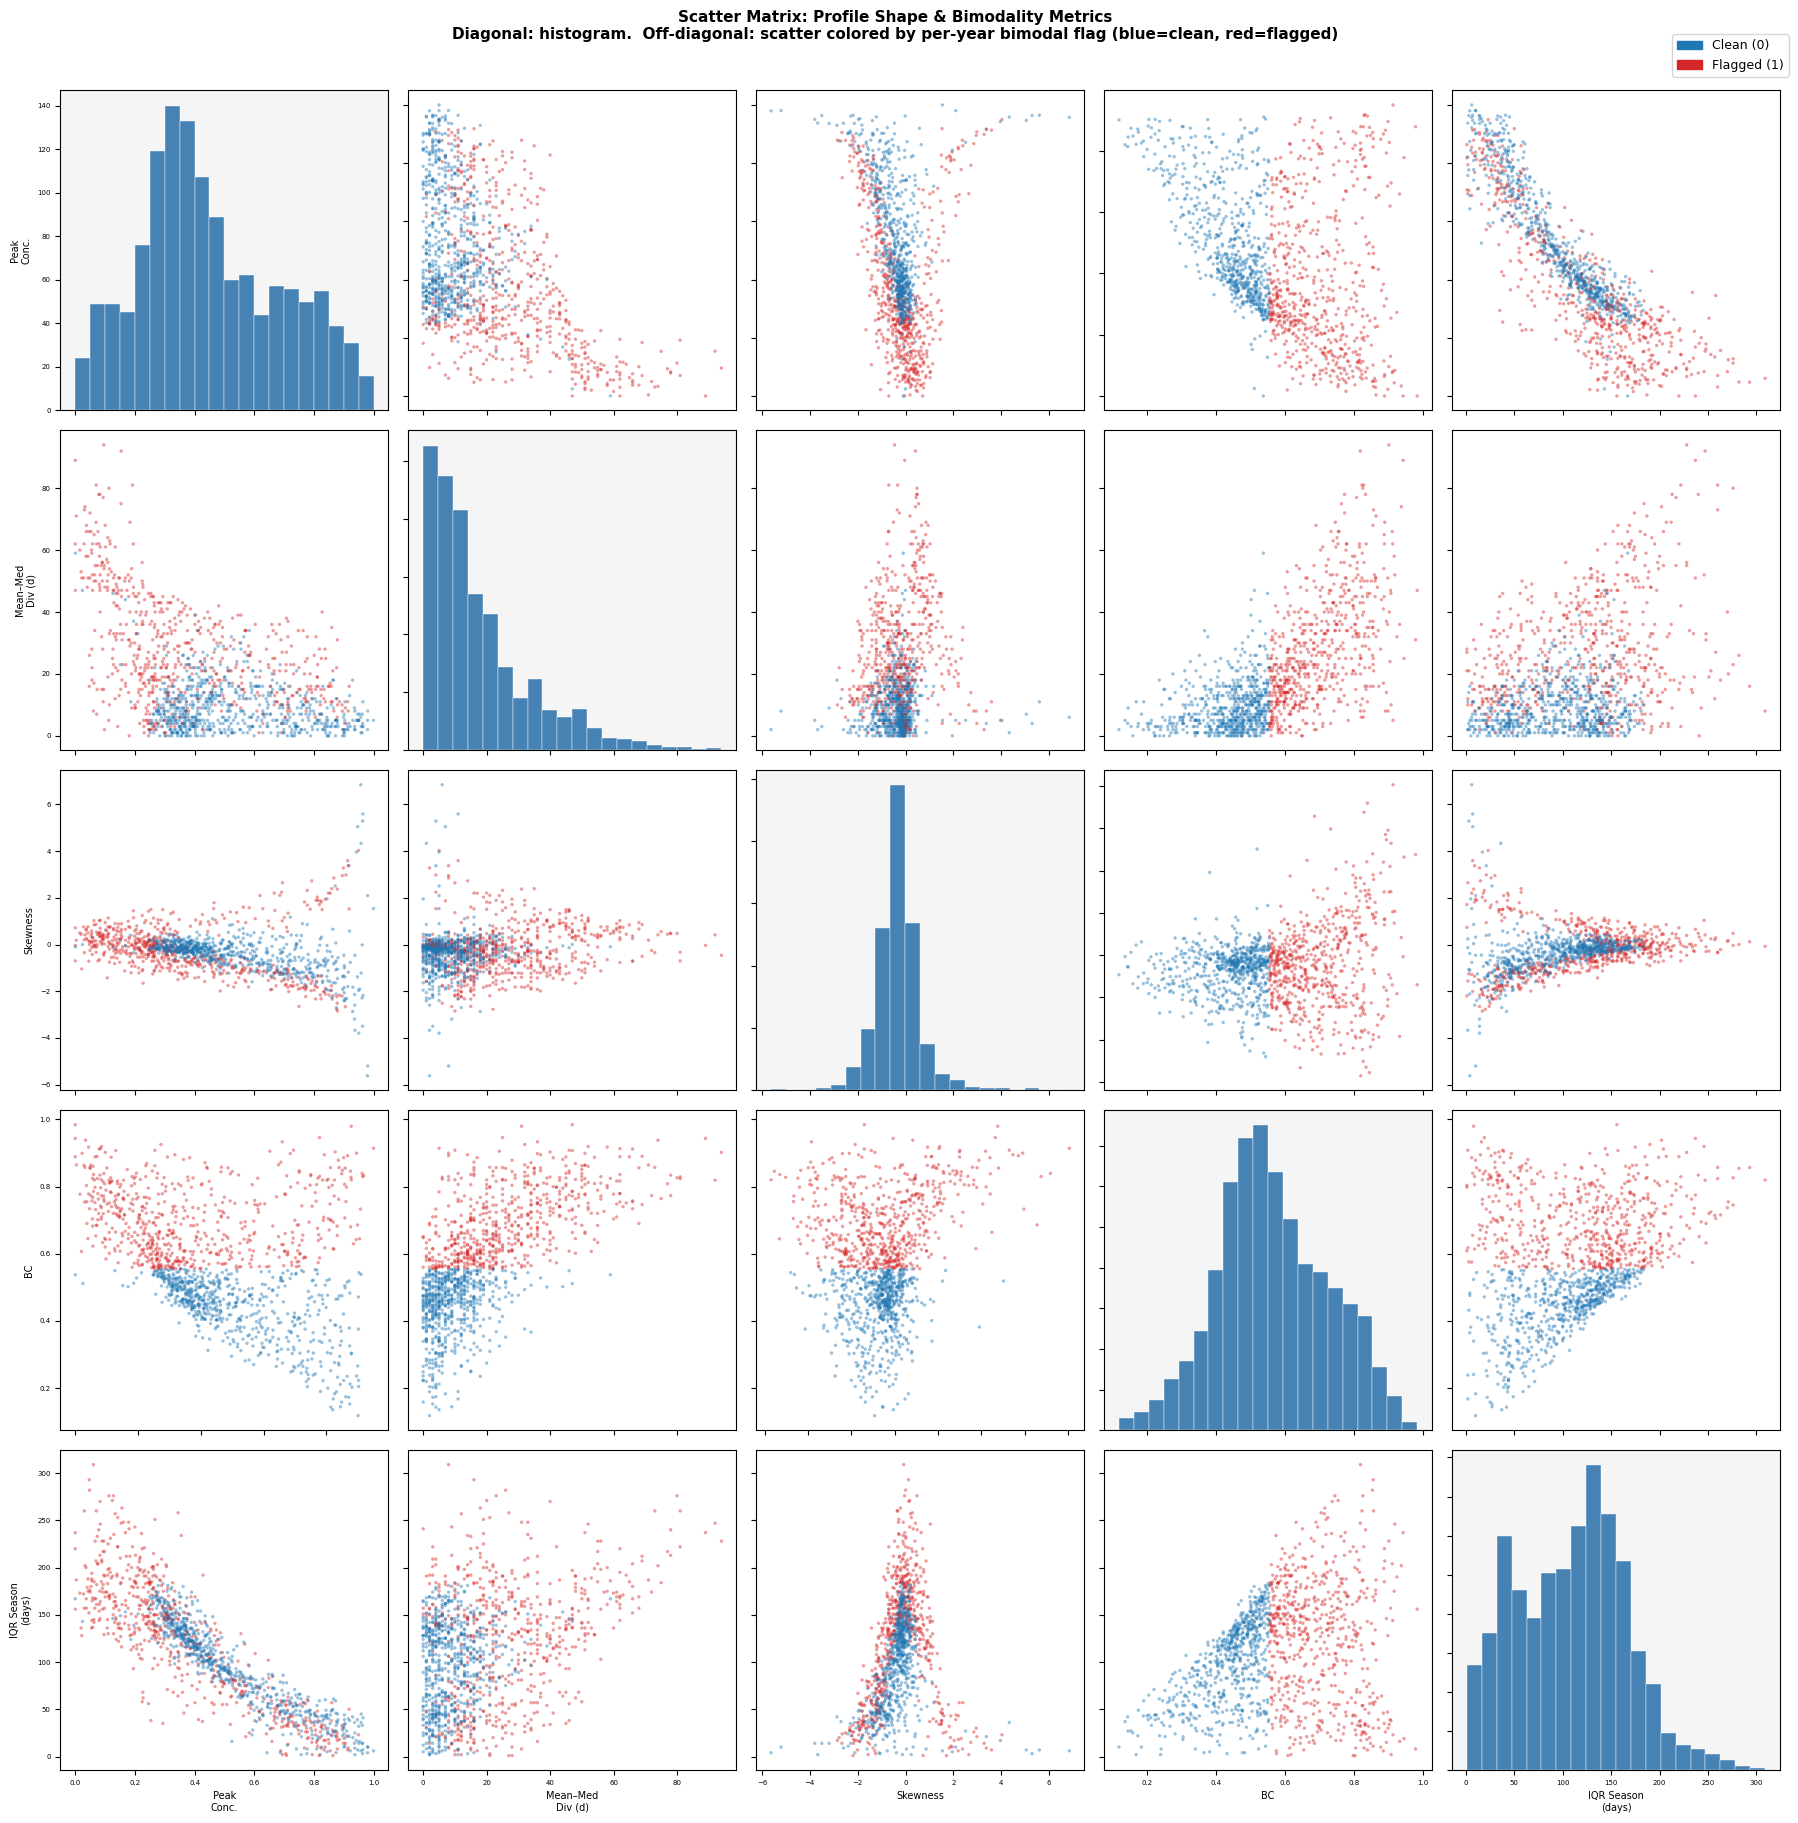

In [12]:
# Plot 09: Scatter Matrix: Profile Shape & Bimodality Metrics --------------------------------------
# Diagonal  : histogram of that variable.
# Off-diagonal : scatter plot of the two variables, colored by bimodal_flag_year.
# Variables chosen to capture profile shape reliability and bimodality risk together.

SCAT_VARS = [
    ('peak_concentration', 'Peak\nConc.'),
    ('mean_median_div',    'Mean–Med\nDiv (d)'),
    ('skewness',           'Skewness'),
    ('bc',                 'BC'),
    ('iqr_season_length',  'IQR Season\n(days)'),
]
N = len(SCAT_VARS)

fig, axes = plt.subplots(N, N, figsize=(18, 18))
fig.suptitle(
    'Scatter Matrix: Profile Shape & Bimodality Metrics\n'
    'Diagonal: histogram.  Off-diagonal: scatter colored by per-year bimodal flag '
    '(blue=clean, red=flagged)',
    fontsize=11, fontweight='bold', y=1.01
)

flag_colors = master_df['bimodal_flag_year'].map(C_FLAGS).fillna('#aaaaaa').values

for i, (var_y, label_y) in enumerate(SCAT_VARS):
    for j, (var_x, label_x) in enumerate(SCAT_VARS):
        ax = axes[i, j]
        x  = master_df[var_x].values.astype(float)
        y  = master_df[var_y].values.astype(float)

        if i == j:
            # Diagonal:  histogram
            valid = ~np.isnan(x)
            ax.hist(x[valid], bins=20,
                    color='steelblue', edgecolor='white', linewidth=0.3)
            ax.set_facecolor('#f5f5f5')
        else:
            # Off-diagonal:  scatter
            valid = ~np.isnan(x) & ~np.isnan(y)
            ax.scatter(x[valid], y[valid],
                       c=flag_colors[valid], s=6, alpha=0.45, linewidths=0)

        # Axis labels on outer edges only
        if i == N - 1:
            ax.set_xlabel(label_x, fontsize=7)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(label_y, fontsize=7)
        else:
            ax.set_yticklabels([])

        ax.tick_params(labelsize=5)

# Legend
legend_handles = [
    mpatches.Patch(color=C_FLAGS[k], label=L_FLAGS[k]) for k in sorted(C_FLAGS)
]
fig.legend(handles=legend_handles, loc='upper right',
           fontsize=9, bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '09_scatter_matrix_shape_bimodality.png'), 
            dpi=FIG_DPI, bbox_inches='tight')
plt.show()

## Section 3: Ridgeline Plot

Saved: 10_ridgeline_proportion_season_length_biome.png


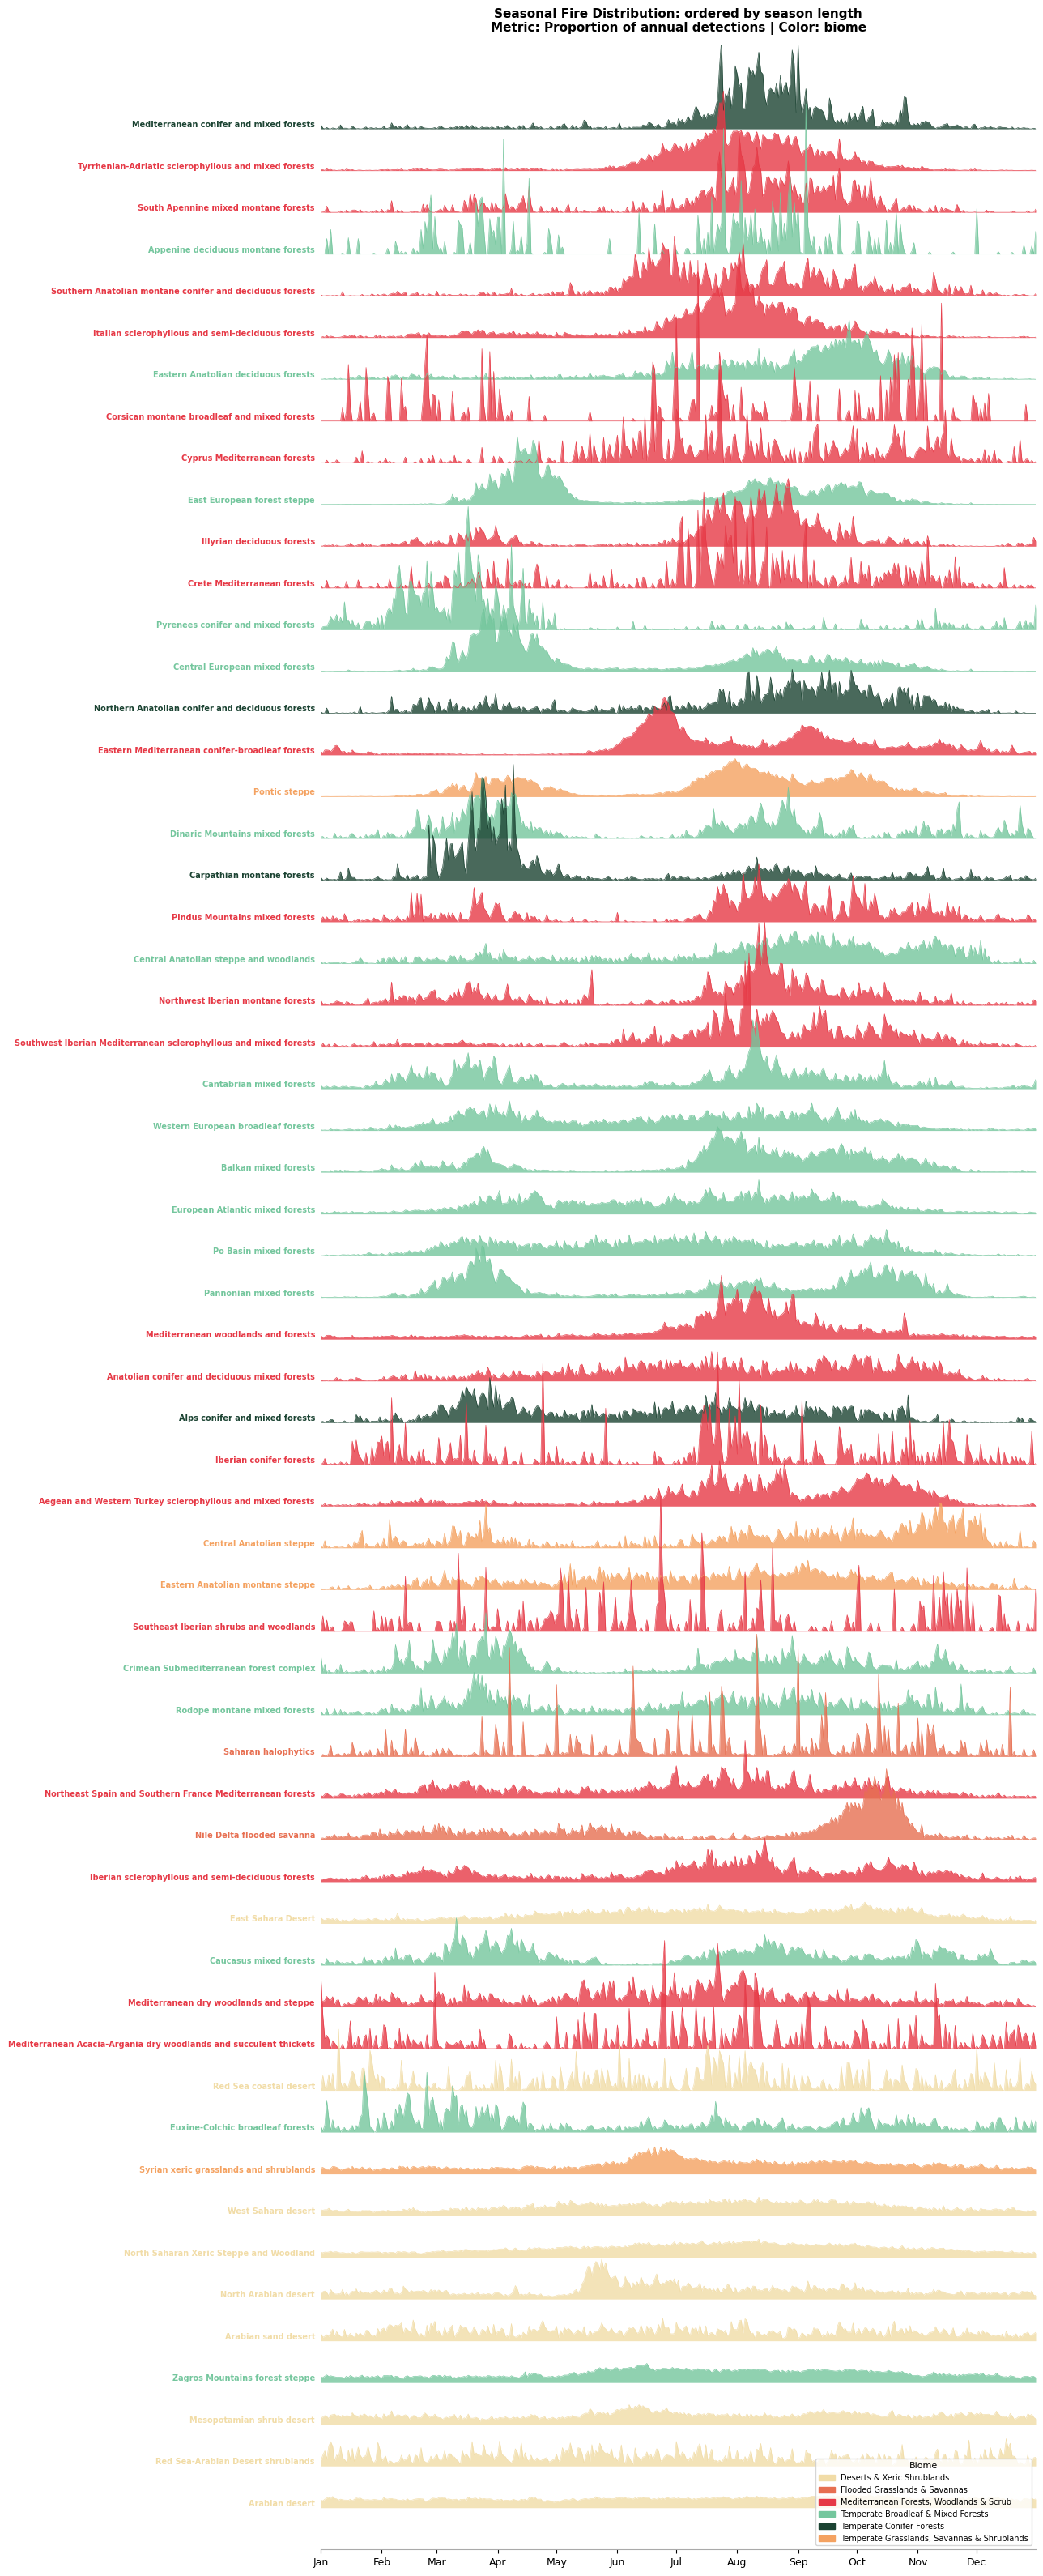

In [14]:
# PLOT 10: RIDGELINE PLOT:  SEASONAL FIRE DISTRIBUTION PER ECOREGION --------------------------
# ── PARAMETERS ────────────────────────────────────────────────────────────────────────────────
RIDGE_METRIC   = 'proportion'   # 'proportion' | 'smoothed_only'
RIDGE_ORDER    = 'season_length'     # 'peak_doy'   | 'onset_doy' | 'season_length'
RIDGE_COLOR    = 'biome'      # 'rainbow' | 'spectral' | 'coolwarm' | 'turbo' | 'biome'
# ──────────────────────────────────────────────────────────────────────────────────────────────

from matplotlib.colors import Normalize, to_rgba
from matplotlib.cm import ScalarMappable
import matplotlib.patches as mpatches

SMOOTH_WIN  = 15
RIDGE_SCALE = 1.4

# --- BIOME COLOR PALETTE ---
BIOME_PALETTE = {
    'Tropical & Subtropical Moist Broadleaf Forests' : '#2d6a4f',
    'Tropical & Subtropical Dry Broadleaf Forests'   : '#52b788',
    'Tropical & Subtropical Coniferous Forests'      : '#40916c',
    'Temperate Broadleaf & Mixed Forests'            : '#74c69d',
    'Temperate Conifer Forests'                      : '#1b4332',
    'Boreal Forests/Taiga'                           : '#081c15',
    'Tropical & Subtropical Grasslands, Savannas'   : '#e9c46a',
    'Temperate Grasslands, Savannas & Shrublands'   : '#f4a261',
    'Flooded Grasslands & Savannas'                  : '#e76f51',
    'Montane Grasslands & Shrublands'                : '#264653',
    'Tundra'                                         : '#a8dadc',
    'Mediterranean Forests, Woodlands & Scrub'      : '#e63946',
    'Deserts & Xeric Shrublands'                     : '#f1dca7',
    'Mangroves'                                      : '#023e8a',
}
BIOME_DEFAULT = '#999999'

# ── STEP 1: BUILD MEAN PROFILES ───────────────────────────────────────────────────────────────
eco_profiles = {}
eco_prop     = {}

for eco_id in master_df['eco_id'].unique():
    eco_daily = daily_df[daily_df['eco_id'] == eco_id].copy()
    if eco_daily.empty:
        continue

    years     = eco_daily['year'].unique()
    full_grid = pd.MultiIndex.from_product(
        [years, range(1, 366)], names=['year', 'doy']
    ).to_frame(index=False)

    eco_full = (
        full_grid
        .merge(eco_daily[['year', 'doy', 'n_detections']], on=['year', 'doy'], how='left')
        .fillna({'n_detections': 0})
    )
    eco_full['year_total'] = eco_full.groupby('year')['n_detections'].transform('sum')
    eco_full['prop'] = np.where(
        eco_full['year_total'] > 0,
        eco_full['n_detections'] / eco_full['year_total'],
        0
    )

    prop_mean = eco_full.groupby('doy')['prop'].mean().values
    smoothed  = pd.Series(prop_mean).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().values

    eco_prop[eco_id]     = prop_mean
    eco_profiles[eco_id] = smoothed

# ── STEP 2: METRIC SELECTION ──────────────────────────────────────────────────────────────────
if RIDGE_METRIC == 'proportion':
    plot_data    = eco_prop
    metric_label = 'Proportion of annual detections'
elif RIDGE_METRIC == 'smoothed_only':
    plot_data    = eco_profiles
    metric_label = 'Smoothed proportion (15-day window)'
else:
    raise ValueError(f"Unknown RIDGE_METRIC: '{RIDGE_METRIC}'. Use 'proportion' or 'smoothed_only'.")

# ── STEP 3: ORDERING ──────────────────────────────────────────────────────────────────────────
if RIDGE_ORDER == 'peak_doy':
    sort_series = master_df.groupby('eco_id')['peak_doy'].mean()
    order_label = 'peak DOY'
elif RIDGE_ORDER == 'onset_doy':
    sort_series = master_df.groupby('eco_id')['onset_doy'].mean()
    order_label = 'onset DOY'
elif RIDGE_ORDER == 'season_length':
    sort_series = master_df.groupby('eco_id')['season_length'].mean()
    order_label = 'season length'
else:
    raise ValueError(f"Unknown RIDGE_ORDER: '{RIDGE_ORDER}'. Use 'peak_doy', 'onset_doy', or 'season_length'.")

eco_order_ridge = (
    sort_series
    .dropna()
    .loc[sort_series.index.isin(plot_data.keys())]
    .sort_values(ascending=True)
    .index.tolist()
)

# ── STEP 4: COLOR SCHEME ──────────────────────────────────────────────────────────────────────
CMAP_OPTIONS = {
    'rainbow'  : 'rainbow',
    'spectral' : 'Spectral',
    'coolwarm' : 'coolwarm',
    'turbo'    : 'turbo',
}

if RIDGE_COLOR == 'biome':
    cmap = None
    norm = None
else:
    if RIDGE_COLOR not in CMAP_OPTIONS:
        raise ValueError(
            f"Unknown RIDGE_COLOR: '{RIDGE_COLOR}'. "
            f"Use one of: {list(CMAP_OPTIONS.keys())} or 'biome'."
        )
    cmap = plt.get_cmap(CMAP_OPTIONS[RIDGE_COLOR])
    norm = Normalize(vmin=sort_series.min(), vmax=sort_series.max())

def get_color(eco_id):
    if RIDGE_COLOR == 'biome':
        biome = master_df.loc[master_df['eco_id'] == eco_id, 'biome_name'].iloc[0]
        return BIOME_PALETTE.get(biome, BIOME_DEFAULT)
    return cmap(norm(sort_series[eco_id]))

# ── STEP 5: PLOT ──────────────────────────────────────────────────────────────────────────────
n_ecos  = len(eco_order_ridge)
fig_h   = max(8, n_ecos * 0.55)
fig, ax = plt.subplots(figsize=(13, fig_h))

doys  = np.arange(1, 366)
SCALE = n_ecos * RIDGE_SCALE

for rank, eco_id in enumerate(eco_order_ridge):
    profile = plot_data[eco_id]
    y_base  = n_ecos - rank
    color   = get_color(eco_id)
    y_vals  = y_base + profile * SCALE

    ax.fill_between(doys, y_base, y_vals, color=color, alpha=0.80, linewidth=0)
    ax.plot(doys, y_vals, color=color, linewidth=0.5, alpha=0.95)

    eco_name = master_df.loc[master_df['eco_id'] == eco_id, 'eco_name'].iloc[0]
    ax.text(-2, y_base, eco_name,
            ha='right', va='bottom', fontsize=7,
            color=color, fontweight='bold')

# ── STEP 6: AXES ──────────────────────────────────────────────────────────────────────────────
ax.set_xlim(1, 365)
ax.set_ylim(0, n_ecos + 2)
ax.set_xticks(MONTH_STARTS)
ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.yaxis.set_visible(False)
ax.spines[['left', 'right', 'top']].set_visible(False)
ax.spines['bottom'].set_color('#aaaaaa')

ax.set_title(
    f'Seasonal Fire Distribution: ordered by {order_label}\n'
    f'Metric: {metric_label} | Color: {RIDGE_COLOR}',
    fontsize=11, fontweight='bold', pad=12
)

# ── STEP 7: LEGEND / COLORBAR ─────────────────────────────────────────────────────────────────
if RIDGE_COLOR in CMAP_OPTIONS:
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.015, pad=0.01)
    cbar.set_label(f'Mean {order_label}', fontsize=9)
    if RIDGE_ORDER in ('peak_doy', 'onset_doy'):
        cbar.set_ticks(MONTH_STARTS)
        cbar.set_ticklabels(MONTH_NAMES, fontsize=7)

elif RIDGE_COLOR == 'biome':
    present_biomes = master_df.loc[
        master_df['eco_id'].isin(eco_order_ridge), 'biome_name'
    ].unique()
    handles = [
        mpatches.Patch(color=BIOME_PALETTE.get(b, BIOME_DEFAULT), label=b)
        for b in sorted(present_biomes)
    ]
    ax.legend(handles=handles, fontsize=7, loc='lower right',
              frameon=True, framealpha=0.8, title='Biome', title_fontsize=8)

plt.tight_layout()

fname = f'10_ridgeline_{RIDGE_METRIC}_{RIDGE_ORDER}_{RIDGE_COLOR}.png'
plt.savefig(os.path.join(plots_dir, fname), dpi=FIG_DPI, bbox_inches='tight')
print(f'Saved: {fname}')
plt.show()